# 3.十种猴子图像分类模型（从零训练）

本章使用 PyTorch 针对 **10 Monkey Species** 数据集，从零开始构建并训练一个卷积神经网络，实现对十种猴子的细粒度图像分类，重点掌握自定义数据集加载与完整训练流程。

**主要内容：**
- 10 Monkey Species 数据集介绍与加载
- 自定义 CNN 网络架构设计
- 数据增强策略与训练技巧
- 模型训练、验证与结果分析
- 使用 TensorBoard 可视化训练过程

## 一、导入依赖库与环境配置

In [97]:
# 导入 matplotlib（绘图库）及其子模块 pyplot（提供类 MATLAB 的绘图接口）
import matplotlib as mpl
import matplotlib.pyplot as plt
# %matplotlib inline：Jupyter 魔法命令，将图表内嵌显示在 notebook 中
%matplotlib inline
# 导入 NumPy（科学计算库，提供多维数组和数学函数）
import numpy as np
# 导入 scikit-learn（机器学习库，此处主要用于 accuracy_score 等评估函数）
import sklearn
# 导入 Pandas（数据分析库，用于 DataFrame 处理训练记录）
import pandas as pd
# 导入 os 模块（操作系统接口，用于目录创建、路径操作等）
import os
# 导入 sys 模块（系统信息，如 Python 版本）
import sys
# 导入 time 模块（时间计算，可用于计时）
import time
# 导入 tqdm 进度条库（auto 版本可自动适配 Jupyter / 命令行环境）
from tqdm import tqdm
# 导入 PyTorch 核心库（深度学习框架）
import torch
# 导入 torch.nn 模块（提供神经网络层、损失函数等）
import torch.nn as nn
# 导入 torch.nn.functional 模块（提供无状态的函数式 API，如 F.relu、F.selu）
import torch.nn.functional as F

# 打印 Python 版本信息（sys.version_info 返回版本元组）
print(sys.version_info)
# 遍历主要依赖库，打印各库的名称和版本号，便于环境确认
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)
    
# 自动检测可用设备：若有 CUDA（GPU），则使用 cuda:0；否则使用 CPU
# torch.cuda.is_available() 返回 bool，表示 CUDA 是否可用
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
# 打印当前使用的计算设备（cpu 或 cuda:0）
print(device)

# 设置全局随机种子（用于保证实验可复现性，可在后续代码中传入 torch.manual_seed(seed) 等）
seed = 42


sys.version_info(major=3, minor=14, micro=5, releaselevel='final', serial=0)
matplotlib 3.10.9
numpy 2.4.6
pandas 3.0.3
sklearn 1.9.0
torch 2.12.0+cu132
cuda:0


## 二、数据准备

### 2.1 自定义 MonkeyDataset 数据集类与图像变换

In [98]:
# 从 torchvision 导入 datasets 模块（包含 ImageFolder 等标准数据集类）
from torchvision import datasets
# 导入常用图像变换类：
# ToTensor: 将 PIL 图像转为 (C,H,W) 格式的 float Tensor，像素值归一化到 [0,1]
# Resize: 将图像调整为指定尺寸 (H, W)
# Compose: 将多个变换串联成一个变换管道
# ConvertImageDtype: 将图像 Tensor 转换为指定数据类型
# Normalize: 对图像各通道进行标准化（(x - mean) / std）
from torchvision.transforms import ToTensor, Resize, Compose, ConvertImageDtype, Normalize

# 导入 pathlib.Path，用于跨平台路径操作（比 os.path 更简洁）
from pathlib import Path  # 引入 Path 类，用于跨平台路径操作。Path 对象支持专门的路径方法（如 / 拼接子路径、exists 检查文件是否存在、iterdir 遍历目录等），这些操作普通字符串（str）无法直接实现。

# 数据集根目录（相对路径，包含 training/ 和 validation/ 两个子目录）
DATA_DIR = Path("./data/archive")

class MonkeyDataset(datasets.ImageFolder):
    """
    自定义猴子图像数据集类，继承自 torchvision.datasets.ImageFolder。
    ImageFolder 会自动将子目录名称作为类别标签，按字母序排列。
    """
    # ImageFolder（即本类的父类）内部实现了 __getitem__ 和 __len__ 魔法方法：
    # 1. __getitem__(self, index): 按索引返回第 index 张图片及标签
    #    返回 (image, label)，其中 image 是经过 transform 处理后的图片张量，label 是类别索引（int）。
    #    可通过 ds[i] 方式获取数据，常用于 PyTorch DataLoader 按批量采样数据时自动调用。
    # 2. __len__(self): 返回数据集大小（图片总数）
    #    len(ds) 就会调用该方法，等价于 samples 或 targets 的长度。
    # 因此，MonkeyDataset 继承 ImageFolder 后自动具备 __getitem__ 和 __len__ 功能，无需重复定义。

    def __init__(self, mode, transform=None):
        """
        初始化数据集，根据 mode 选择训练集或验证集目录。

        Args:
            mode (str): 数据集模式，"train" 使用 training/ 目录，"val" 使用 validation/ 目录。
            transform (callable, optional): 图像变换管道，应用于每张图片，默认为 None。
        """
        # 根据 mode 选择对应的数据目录
        if mode == "train":
            root = DATA_DIR / "training"      # 训练集目录路径
        elif mode == "val":
            root = DATA_DIR / "validation"    # 验证集目录路径
        else:
            # mode 参数无效时抛出 ValueError 异常
            raise ValueError("mode should be one of the following: train, val, but got {}".format(mode))
        # 调用父类 ImageFolder 的初始化方法，自动扫描 root 目录下的图片文件
        super().__init__(root,transform) # 调用父类init方法
        # self.imgs = self.samples
        # self.samples 是 ImageFolder 原生属性，存储全部 (路径, 标签) 元组列表
        # self.imgs 是 self.samples 的别名，两者完全等价
        #
        # self.targets 并非 ImageFolder 的原生属性，而是在本类 __init__ 中手动添加的：
        # 从 self.samples 中提取第二个元素（整数类别索引），构造成纯标签列表。
        # 属性类型：list[int]
        # 作用：方便后续按标签统计样本分布、执行分层采样（StratifiedSampler）等操作，
        #       无需每次从 samples 中解包，直接通过 train_ds.targets[i] 即可获得第 i 张图的标签。
        self.targets = [s[1] for s in self.samples] # 标签取出来，与 samples 一一对应

# 预先设定图片的目标尺寸（高度、宽度），所有图片将被缩放到此尺寸
img_h, img_w = 128, 128
# 定义图像预处理变换管道（Compose 按顺序依次应用各变换）
transform = Compose([
    Resize((img_h, img_w)), # 将图片缩放/裁剪到 (128, 128)
    # 为什么要Resize? 深度学习模型通常要求批量输入具有统一的尺寸，才能组成张量进行并行计算。
    # 猴子图片原始尺寸各异，如果不Resize则无法组成形状一致的批量数据。
    # 此处将所有图片调整为统一的(128,128)，保证后续模型训练、推理的正常进行。
    ToTensor(),  # PIL Image → (C,H,W) float Tensor，像素值从 [0,255] 归一化到 [0.0,1.0]
    # Normalize 参数：mean=[R均值,G均值,B均值], std=[R标准差,G标准差,B标准差]
    # 变换公式：output = (input - mean) / std，使各通道分布中心化
    ConvertImageDtype(torch.float), # 确保输出为 float32 类型
]) # 数据预处理管道定义完成


# 创建训练集数据集对象（加载 archive/training/ 下的所有图片，并应用 transform）
train_ds = MonkeyDataset("train", transform=transform)
# 创建验证集数据集对象（加载 archive/validation/ 下的所有图片，并应用相同 transform）
val_ds = MonkeyDataset("val",transform=transform)

# 打印数据集加载统计信息
print("load {} images from training dataset".format(len(train_ds)))    # 训练集图片总数
print("load {} images from validation dataset".format(len(val_ds)))    # 验证集图片总数

load 1097 images from training dataset
load 272 images from validation dataset


### 2.2 查看数据集类别与索引映射

In [99]:
# train_ds.classes 是 ImageFolder（继承自父类 torchvision.datasets.DatasetFolder）的实例属性
# 在 ImageFolder.__init__ 内部调用 find_classes(root) 方法自动扫描 root 目录，
# 将每个子文件夹名称作为一个类别，按字母序排列后赋值给 self.classes。
# 因此用户无需手动定义，只要 MonkeyDataset 继承了 ImageFolder 并调用 super().__init__()，
# self.classes 就会自动被创建并填充。
#
# 属性类型：list[str]
# 返回值：数据集中所有类别名称的有序列表
# 类别名对应 archive/training/ 目录下各子文件夹的名称（如 'n0', 'n1', ..., 'n9'）
# 列表顺序即为类别索引的顺序（索引 0 → 'n0'，索引 1 → 'n1'，以此类推）
train_ds.classes

['n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9']

In [100]:
# train_ds.class_to_idx 是 ImageFolder（继承自 DatasetFolder）的实例属性
# 在 DatasetFolder.__init__ 中由 find_classes(root) 一并生成，与 self.classes 同步创建。
# find_classes() 扫描 root 目录后返回 (classes, class_to_idx) 两个对象：
#   - classes      → list[str]，类别名称有序列表（见上一个 cell）
#   - class_to_idx → dict[str, int]，类别名称到整数索引的映射
#
# 属性类型：dict[str, int]
# 返回值：形如 {'n0': 0, 'n1': 1, ..., 'n9': 9} 的字典
# 作用：在加载每张图片时，根据图片所在子目录名称查询此字典，
#       得到对应的整数标签（label），存入 self.samples 的第二个元素。
train_ds.class_to_idx

{'n0': 0,
 'n1': 1,
 'n2': 2,
 'n3': 3,
 'n4': 4,
 'n5': 5,
 'n6': 6,
 'n7': 7,
 'n8': 8,
 'n9': 9}

### 2.3 查看图片路径与标签

In [101]:
# train_ds.samples 是 ImageFolder（继承自 DatasetFolder）的实例属性
# 在 DatasetFolder.__init__ 中由 make_dataset(root, class_to_idx, ...) 函数生成：
#   递归扫描 root 下所有子目录，将每张合法图片的路径与对应的类别索引组成元组，
#   最终汇总为一个有序列表赋值给 self.samples。
#
# 属性类型：list[tuple[str, int]]
# 元素格式：(image_path, class_index)
#   - image_path  (str)：图片文件的完整路径
#   - class_index (int)：该图片所属类别的整数索引（与 class_to_idx 一致）
# len(train_ds.samples) == len(train_ds)，即数据集总图片数
#
# 注意：train_ds.imgs 是 self.samples 的别名，两者完全等价。
#
# 打印训练集前 10 张图片的文件路径和对应类别标签
i = 0  # 计数器，用于控制只打印前 10 条
for fpath, label in train_ds.samples:
    # fpath: 图片文件的绝对/相对路径（str）
    # label: 类别索引（int），如 0 对应 "n0"（mantled_howler）
    print(fpath, label)
    i += 1
    if i == 10:
        break  # 打印 10 条后退出循环
#
# 以下为备用遍历方式（已注释）：直接迭代数据集，得到经过 transform 后的图像张量和标签
# for img, label in train_ds:
#     # img: 经过 transform 变换的图像张量，形状为 (C, H, W)
#     # label: 类别索引（int）
#     print(img, label)
#     break

data\archive\training\n0\n0018.jpg 0
data\archive\training\n0\n0019.jpg 0
data\archive\training\n0\n0020.jpg 0
data\archive\training\n0\n0021.jpg 0
data\archive\training\n0\n0022.jpg 0
data\archive\training\n0\n0023.jpg 0
data\archive\training\n0\n0024.jpg 0
data\archive\training\n0\n0025.jpg 0
data\archive\training\n0\n0026.jpg 0
data\archive\training\n0\n0027.jpg 0


### 2.4 计算各通道均值与标准差（用于 Normalize 变换）

In [102]:
# 因为图片有 3 个颜色通道（R/G/B），所以需要计算 3 个 mean 和 3 个 std
# 注意：std 不满足线性可加性，不能对每张图的 std 直接取平均。
# 正确做法：利用方差公式 Var(X) = E[X²] - (E[X])²，
# 在遍历过程中分别累积像素一阶矩（sum）和二阶矩（sum of squares），
# 最后一次性计算全局均值和标准差。
def cal_mean_std(ds):
    """
    计算数据集各通道的全局均值与标准差。

    原理：
        设数据集共有 N 张图，每张图空间尺寸为 H×W，通道数为 C。
        对于第 c 个通道，所有图所有像素的集合记为 X_c。

        全局均值：mean_c = sum(X_c) / (N * H * W)

        全局方差利用二阶矩公式避免两次遍历：
            Var(X_c) = E[X_c²] - (E[X_c])²
                     = sum(X_c²) / (N * H * W) - mean_c²

        全局标准差：std_c = sqrt(Var(X_c))

    Args:
        ds (Dataset): 图像数据集，每项返回 (img_tensor, label)，
                      img_tensor 形状为 (C, H, W)，像素值已归一化到 [0, 1]。

    Returns:
        tuple[Tensor, Tensor]:
            - mean: 形状 (C,)，各通道全局均值
            - std:  形状 (C,)，各通道全局标准差
    """
    # 取第一张图以确定通道数 C 和每张图的像素总数 H*W
    first_img, _ = ds[0]
    # first_img.shape = (C, H, W)；numel() 返回张量中元素总数 C*H*W
    # 单张图每通道像素数 = H * W
    num_pixels_per_img = first_img.shape[1] * first_img.shape[2]  # H * W
    # 通道数 C（RGB 图为 3）
    num_channels = first_img.shape[0]

    # pixel_sum[c]   累积第 c 通道所有图所有像素之和，用于计算 E[X]
    # pixel_sum_sq[c] 累积第 c 通道所有图所有像素的平方和，用于计算 E[X²]
    # 初始化为全零张量，形状 (C,)
    pixel_sum    = torch.zeros(num_channels)  # 一阶矩累加器，形状 (C,)
    pixel_sum_sq = torch.zeros(num_channels)  # 二阶矩累加器，形状 (C,)

    # 遍历数据集的每张图像；_ 忽略标签
    for img, _ in ds:
        # img 形状 (C, H, W)
        # .sum(dim=(1, 2))：在 H 和 W 维度上求和，结果形状 (C,)，
        # 即每通道的像素总和
        pixel_sum    += img.sum(dim=(1, 2))
        # img ** 2 对每个像素求平方，再沿 H、W 维度求和，结果形状 (C,)
        pixel_sum_sq += (img ** 2).sum(dim=(1, 2))

    # 数据集总像素数 = 图片数量 * 单张图每通道像素数
    total_pixels = len(ds) * num_pixels_per_img  # 标量，int

    # 全局均值：各通道像素总和 / 总像素数，结果形状 (C,)
    mean = pixel_sum / total_pixels

    # 全局方差：E[X²] - (E[X])²，结果形状 (C,)
    # pixel_sum_sq / total_pixels 为 E[X²]，mean ** 2 为 (E[X])²
    var = pixel_sum_sq / total_pixels - mean ** 2

    # 全局标准差：方差开根号；clamp(min=0) 防止浮点误差导致极小负数
    std = torch.sqrt(var.clamp(min=0))  # 形状 (C,)

    # 返回元组 (均值张量, 标准差张量)，形状均为 (C,)，C=3 对应 R/G/B
    return mean, std

ds_mean, ds_std = cal_mean_std(train_ds)
print("三个通道的均值为:", ds_mean)
print("三个通道的标准差为:", ds_std)

三个通道的均值为: tensor([0.4363, 0.4328, 0.3291])
三个通道的标准差为: tensor([0.2427, 0.2382, 0.2413])


### 2.5 将 Normalize 封装为模型变换层

In [85]:
# 将 Normalize 封装进 nn.Sequential，作为模型的第一个变换层。
# 这样做的好处：
#   1. 归一化在模型内部完成，数据预处理管道无需额外处理
#   2. 模型部署时只需输入原始 [0,1] 的图像，结构更自包含
#   3. torchvision.transforms.Normalize 本身继承自 nn.Module，
#      可以直接放入 nn.Sequential，并随模型迁移到 GPU
#
# 注意：Normalize(mean, std) 的参数格式：
#   mean / std 均为长度等于通道数 C 的列表（每通道一个浮点值）
#   ds_mean / ds_std 是形状 (C,) 的张量，需用 .tolist() 转为 Python 浮点列表
#   直接写 [ds_mean] 会变成含有一个张量的列表，类型不对，会报错！

# .tolist()：将形状 (C,) 的张量转为 Python 浮点列表，例如 [0.436, 0.433, 0.329]
# 这是 Normalize 期望的 mean / std 参数格式（list[float]，长度等于通道数 C）
normalize_layer = nn.Sequential(
    Normalize(ds_mean.tolist(), ds_std.tolist())  # 对 RGB 三通道执行逐通道标准化：(x - mean) / std
)

# 打印变换层结构，确认 Normalize 的均值和标准差参数已正确加载
print(normalize_layer)

Sequential(
  (0): Normalize(mean=[0.43633201718330383, 0.43280699849128723, 0.32910001277923584], std=[0.24267175793647766, 0.23820997774600983, 0.24130727350711823])
)


### 2.6 创建 DataLoader 数据加载器

In [86]:
# 导入 nn 模块（包含神经网络层、损失函数等）
import torch.nn as nn
# 导入 DataLoader：用于将 Dataset 封装成可迭代的批量数据加载器
from torch.utils.data.dataloader import DataLoader    

# 每个批次包含的样本数（批大小）
batch_size = 64
# 注意：在 Windows 多进程场景下，DataLoader 的 num_workers 参数可能导致报错，此处不设置
# 参考：https://github.com/pytorch/pytorch/issues/59438
# 训练集 DataLoader：shuffle=True 表示每个 epoch 开始时随机打乱样本顺序（防止过拟合）
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
# 验证集 DataLoader：shuffle=False 表示按顺序加载，验证时无需打乱
val_loader = DataLoader(val_ds, batch_size=batch_size*2, shuffle=False)

In [87]:
# 从 train_loader 取出第一个批次，验证数据维度是否正确
for imgs, labels in train_loader:
    # imgs.shape 应为 (batch_size, channels, height, width) = (64, 3, 128, 128)
    print(imgs.shape)
    # labels.shape 应为 (batch_size,) = (64,)，每个值为 0~9 的类别索引
    print(labels.shape)
    break  # 只取第一个批次即可，退出循环

torch.Size([64, 3, 128, 128])
torch.Size([64])


## 三、定义 CNN 模型

In [88]:
# 定义 CNN 图像分类模型（共 3 个卷积块，每块含卷积→BN→激活结构，全连接层加 BN + AlphaDropout）
class CNN(nn.Module):
    def __init__(self, num_classes=10, drop_p=0.5):
        """
        初始化 CNN 模型结构。

        新增特性：
          - 前向传播第一步使用外部定义的 normalize_layer 完成逐通道标准化
          - 每个卷积层后接 BatchNorm2d，稳定训练、加速收敛
          - 每个全连接层（最后输出层除外）后接 BatchNorm1d + AlphaDropout
          - 权重使用适合 ReLU 的 Kaiming 均匀初始化（fan_in 模式）

        Args:
            num_classes (int): 分类类别数，默认为 10（对应 10 种猴子）。
            drop_p     (float): AlphaDropout 的丢弃概率，默认 0.5。
        """
        # 调用父类 nn.Module 的初始化方法（必须在最前）
        super(CNN, self).__init__()

        # ---------- 卷积块 1：输入 3 通道 → 32 通道 ----------
        # Conv2d 参数：in_channels=输入通道数，out_channels=输出通道数，
        #             kernel_size=卷积核尺寸，padding="same" 保持空间分辨率不变
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding="same")
        # BatchNorm2d(32)：对 32 通道的特征图做批归一化，加速收敛并抑制内部协变量偏移
        # num_features 须与上一层输出通道数一致
        self.bn1 = nn.BatchNorm2d(num_features=32)
        # 第 2 个卷积层：32 通道 → 32 通道（加深特征提取能力）
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding="same")
        # 对应 bn2：同卷积块 1 的 conv2 输出通道数
        self.bn2 = nn.BatchNorm2d(num_features=32)
        # MaxPool2d(2, 2)：2×2 最大池化，步长为 2，空间尺寸减半（128→64→32→16）
        self.pool = nn.MaxPool2d(2, 2)

        # ---------- 卷积块 2：32 通道 → 64 通道 ----------
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding="same")
        self.bn3 = nn.BatchNorm2d(num_features=64)
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding="same")
        self.bn4 = nn.BatchNorm2d(num_features=64)

        # ---------- 卷积块 3：64 通道 → 128 通道 ----------
        self.conv5 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding="same")
        self.bn5 = nn.BatchNorm2d(num_features=128)
        self.conv6 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding="same")
        self.bn6 = nn.BatchNorm2d(num_features=128)

        # Flatten 层：将多维特征图展平为一维向量，便于输入全连接层
        self.flatten = nn.Flatten()

        # 全连接层 fc1：输入维度 = 128 × 16 × 16（3 次池化后空间尺寸为 16×16，128 通道）
        # input shape is (3, 128, 128) → 3 次池化后 → (128, 16, 16) → flatten → 32768
        self.fc1 = nn.Linear(128 * 16 * 16, 128)
        # BatchNorm1d(128)：对全连接层输出的 128 维向量做批归一化
        # num_features 须与 fc1 输出维度一致
        self.bn_fc1 = nn.BatchNorm1d(num_features=128)
        # AlphaDropout：专为 SELU 设计，但对 ReLU 同样有正则化效果；
        # 与普通 Dropout 不同，它保持均值和方差不变，数值更稳定
        # p=drop_p：每个神经元被置为负饱和值的概率
        self.dropout = nn.AlphaDropout(p=drop_p)

        # 全连接层 fc2：128 → num_classes，输出各类别的原始得分（logits）
        # 最后一层不加 BN 和 Dropout，保证 logits 数值范围不被截断
        self.fc2 = nn.Linear(128, num_classes)

        # 调用权重初始化方法
        self.init_weights()

    def init_weights(self):
        """
        使用 Kaiming 均匀初始化卷积层和全连接层权重，偏置初始化为 0。

        Kaiming（He）初始化专为 ReLU 激活函数设计：
          - mode="fan_in"：根据输入节点数缩放，前向传播时方差稳定
          - nonlinearity="relu"：自动计算适配 ReLU 的增益系数（√2）
          - 相比 Xavier，Kaiming 在深层网络中能更有效地防止梯度消失/爆炸
        BN 层的 weight（γ）初始化为 1、bias（β）初始化为 0（PyTorch 默认已如此）。
        """
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                # Kaiming 均匀初始化：fan_in 模式 + relu 增益，适合 ReLU 激活函数
                nn.init.kaiming_uniform_(m.weight, mode="fan_in", nonlinearity="relu")
                # 偏置初始化为零（BN 存在时偏置影响可忽略，但保持一致性）
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                # BN 层：γ（weight）初始化为 1，β（bias）初始化为 0，保证初始恒等变换
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        """
        前向传播：先通过 normalize_layer 归一化，再依次经过 3 个卷积块（含 BN）、
        展平层和 2 个全连接层（fc1 含 BN + AlphaDropout，fc2 直接输出 logits）。

        Args:
            x (Tensor): 输入图像批次，像素值范围 [0, 1]，
                        形状为 (batch_size, 3, H, W)。

        Returns:
            Tensor: 各类别的原始得分（logits），形状为 (batch_size, num_classes)。
        """
        # ── 归一化层：将 [0,1] 像素值标准化为零均值单位方差，normalize_layer 定义于模型外部
        # normalize_layer 为全局 nn.Sequential，包含 Normalize(ds_mean, ds_std)
        x = normalize_layer(x)

        # ── 卷积块 1：conv1 → BN → ReLU → conv2 → BN → ReLU → MaxPool
        # 顺序：先卷积提取特征，再 BN 归一化，最后 ReLU 激活（Conv-BN-ReLU 标准顺序）
        # 池化后空间尺寸：128×128 → 64×64
        x = self.pool(F.relu(self.bn2(self.conv2(F.relu(self.bn1(self.conv1(x)))))))

        # ── 卷积块 2：conv3 → BN → ReLU → conv4 → BN → ReLU → MaxPool
        # 池化后空间尺寸：64×64 → 32×32
        x = self.pool(F.relu(self.bn4(self.conv4(F.relu(self.bn3(self.conv3(x)))))))

        # ── 卷积块 3：conv5 → BN → ReLU → conv6 → BN → ReLU → MaxPool
        # 池化后空间尺寸：32×32 → 16×16
        x = self.pool(F.relu(self.bn6(self.conv6(F.relu(self.bn5(self.conv5(x)))))))

        # ── 展平：(batch, 128, 16, 16) → (batch, 32768)
        x = self.flatten(x)

        # ── 全连接块：fc1 → BN1d → ReLU → AlphaDropout
        # BN1d 在全连接层后对特征向量做批归一化，AlphaDropout 提供正则化
        x = self.dropout(F.relu(self.bn_fc1(self.fc1(x))))

        # ── 输出层：fc2 → logits，不加激活（交叉熵损失内含 softmax）
        logits = self.fc2(x)
        return logits


# 遍历 CNN 模型的所有命名参数，打印参数名称和参数量
# named_parameters() 返回 (name, tensor) 的迭代器
# np.prod(value.shape) 计算该参数张量的元素总数
for idx, (key, value) in enumerate(CNN().named_parameters()):
    print(f"{key}\tparamerters num: {np.prod(value.shape)}")


conv1.weight	paramerters num: 864
conv1.bias	paramerters num: 32
bn1.weight	paramerters num: 32
bn1.bias	paramerters num: 32
conv2.weight	paramerters num: 9216
conv2.bias	paramerters num: 32
bn2.weight	paramerters num: 32
bn2.bias	paramerters num: 32
conv3.weight	paramerters num: 18432
conv3.bias	paramerters num: 64
bn3.weight	paramerters num: 64
bn3.bias	paramerters num: 64
conv4.weight	paramerters num: 36864
conv4.bias	paramerters num: 64
bn4.weight	paramerters num: 64
bn4.bias	paramerters num: 64
conv5.weight	paramerters num: 73728
conv5.bias	paramerters num: 128
bn5.weight	paramerters num: 128
bn5.bias	paramerters num: 128
conv6.weight	paramerters num: 147456
conv6.bias	paramerters num: 128
bn6.weight	paramerters num: 128
bn6.bias	paramerters num: 128
fc1.weight	paramerters num: 4194304
fc1.bias	paramerters num: 128
bn_fc1.weight	paramerters num: 128
bn_fc1.bias	paramerters num: 128
fc2.weight	paramerters num: 1280
fc2.bias	paramerters num: 10


### 3.1 统计模型可训练参数量

In [89]:
# 定义辅助函数：统计模型中所有可训练参数的总数量
def count_parameters(model):
    """
    计算模型中所有 requires_grad=True 的参数总数量。

    Args:
        model (nn.Module): 要统计参数量的 PyTorch 模型。

    Returns:
        int: 可训练参数的总数量（各参数张量元素个数之和）。
    """
    # p.numel() 返回张量 p 中的元素总数（如形状 (32, 3, 3, 3) 的参数有 32*3*3*3=864 个）
    # p.requires_grad 为 True 表示该参数参与梯度计算（即可训练参数）
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# 创建 CNN 实例并统计总参数量
count_parameters(CNN())

4483882

## 四、模型训练

PyTorch 的训练循环需要手动实现，主要包含以下步骤：
1. 定义损失函数
2. 定义优化器
3. 定义训练步（前向传播 → 计算损失 → 反向传播 → 参数更新）
4. 完整训练循环（含周期性评估、TensorBoard 记录、检查点保存、早停）

### 4.1 定义评估函数

In [90]:
# 从 sklearn 中导入准确率计算函数
# accuracy_score(y_true, y_pred): 计算分类准确率，返回 0~1 的浮点数
from sklearn.metrics import accuracy_score

# @torch.no_grad() 装饰器：在评估时禁用梯度计算，节省显存并加速推理
@torch.no_grad()
def evaluating(model, dataloader, loss_fct):
    """
    在给定数据集上评估模型性能，计算平均损失和准确率。

    Args:
        model (nn.Module): 待评估的模型（应处于 eval 模式）。
        dataloader (DataLoader): 验证集或测试集的 DataLoader。
        loss_fct (callable): 损失函数，如 nn.CrossEntropyLoss()。

    Returns:
        tuple: (avg_loss, accuracy)
            - avg_loss (float): 所有批次损失的均值。
            - accuracy (float): 整个数据集上的分类准确率（0~1）。
    """
    # 用于存储每个批次的损失值
    loss_list = []
    # 用于存储所有批次的预测标签
    pred_list = []
    # 用于存储所有批次的真实标签
    label_list = []
    model.eval()  # 切换为评估模式
    for datas, labels in dataloader:
        # 将图像数据移动到目标设备（GPU/CPU）
        datas = datas.to(device)
        # 将标签移动到目标设备
        labels = labels.to(device)
        # 前向传播：得到每个类别的原始得分（logits）
        logits = model(datas)
        # 计算当前批次的交叉熵损失
        loss = loss_fct(logits, labels)         # 验证集损失（标量 Tensor）
        # 提取标量值并追加到损失列表
        loss_list.append(loss.item())
        
        # 取得分最高的类别索引作为预测结果（axis=-1 沿类别维度取 argmax）
        preds = logits.argmax(axis=-1)    # 验证集预测结果，形状 (batch_size,)
        # 将预测结果转回 CPU numpy 列表并累积
        pred_list.extend(preds.cpu().numpy().tolist())
        # 将真实标签转回 CPU numpy 列表并累积
        label_list.extend(labels.cpu().numpy().tolist())
        
    # 用 sklearn 计算整个验证集的准确率（预测正确样本数 / 总样本数）
    acc = accuracy_score(label_list, pred_list)
    # 返回所有批次的平均损失和总体准确率
    return np.mean(loss_list), acc


### 4.2 TensorBoard 可视化回调（TensorBoardCallback）

训练过程中可以使用如下命令启动 TensorBoard 服务，实时查看 loss/accuracy/learning_rate 曲线。

```shell
tensorboard \
    --logdir=runs \     # log 存放路径（与代码中的 log_dir 一致）
    --host 0.0.0.0 \    # 监听的 IP 地址（0.0.0.0 表示监听所有网卡）
    --port 8848         # 监听端口号
```

In [91]:
# 从 PyTorch 的 tensorboard 集成模块中导入 SummaryWriter
# SummaryWriter 用于将标量、图像、模型结构等信息写入 TensorBoard 日志文件
from torch.utils.tensorboard import SummaryWriter


class TensorBoardCallback:
    """TensorBoard 可视化回调类：将训练过程中的 loss、accuracy、learning_rate 写入日志"""

    def __init__(self, log_dir, flush_secs=10):
        """
        初始化 TensorBoard 回调。

        Args:
            log_dir (str): TensorBoard 日志文件的保存目录，如 "runs/monkeys-cnn-relu"。
            flush_secs (int, optional): 每隔多少秒将缓冲区数据刷写到磁盘，默认为 10 秒。
        """
        # 创建 SummaryWriter 实例，负责日志文件的写入
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs)

    def draw_model(self, model, input_shape):
        """
        将模型计算图写入 TensorBoard，便于可视化模型结构。

        Args:
            model (nn.Module): 待可视化的 PyTorch 模型。
            input_shape (list): 虚拟输入张量的形状，如 [1, 3, 128, 128]。
        """
        # add_graph() 接受模型和一个示例输入，生成计算图
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape))
        
    def add_loss_scalars(self, step, loss, val_loss):
        """
        向 TensorBoard 写入训练集与验证集的损失值（对比曲线）。

        Args:
            step (int): 当前全局训练步数（横坐标）。
            loss (float): 当前步训练集损失。
            val_loss (float): 当前步验证集损失。
        """
        # add_scalars() 在同一图中绘制多条曲线
        self.writer.add_scalars(
            main_tag="training/loss",   # 图表标签（TensorBoard 侧边栏分组名）
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},  # 曲线名称 → 数值
            global_step=step,           # 横坐标（全局步数）
            )
        
    def add_acc_scalars(self, step, acc, val_acc):
        """
        向 TensorBoard 写入训练集与验证集的准确率（对比曲线）。

        Args:
            step (int): 当前全局训练步数。
            acc (float): 当前步训练集准确率（0~1）。
            val_acc (float): 当前步验证集准确率（0~1）。
        """
        self.writer.add_scalars(
            main_tag="training/accuracy",
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc},
            global_step=step,
        )
        
    def add_lr_scalars(self, step, learning_rate):
        """
        向 TensorBoard 写入当前学习率变化曲线。

        Args:
            step (int): 当前全局训练步数。
            learning_rate (float): 当前步的学习率值。
        """
        self.writer.add_scalars(
            main_tag="training/learning_rate",
            tag_scalar_dict={"learning_rate": learning_rate},
            global_step=step,
        )
    
    def __call__(self, step, **kwargs):
        """
        在每次验证评估后调用，将当前 step 的各项指标写入 TensorBoard。

        Args:
            step (int): 当前全局训练步数。
            **kwargs: 关键字参数，支持 loss、val_loss、acc、val_acc、lr。
        """
        # 从 kwargs 中取出 loss 和 val_loss（不存在则为 None）
        loss = kwargs.pop("loss", None)
        val_loss = kwargs.pop("val_loss", None)
        # 若两者均有值，则写入 loss 对比曲线
        if loss is not None and val_loss is not None:
            self.add_loss_scalars(step, loss, val_loss)
        # 从 kwargs 中取出 acc 和 val_acc
        acc = kwargs.pop("acc", None)
        val_acc = kwargs.pop("val_acc", None)
        # 若两者均有值，则写入 accuracy 对比曲线
        if acc is not None and val_acc is not None:
            self.add_acc_scalars(step, acc, val_acc)
        # 从 kwargs 中取出当前学习率
        learning_rate = kwargs.pop("lr", None)
        # 若有值，则写入 learning_rate 曲线
        if learning_rate is not None:
            self.add_lr_scalars(step, learning_rate)


### 4.3 保存最优模型回调（SaveCheckpointsCallback）


In [92]:
class SaveCheckpointsCallback:
    """模型检查点保存回调类：按验证步间隔自动保存最优模型权重"""

    def __init__(self, save_dir,save_best_only=True):
        """
        初始化检查点保存回调。
        本实现以步数（step）为粒度保存检查点。

        Args:
            save_dir (str): 检查点文件的保存目录路径。
            save_best_only (bool, optional): 若为 True，只保存验证集指标最优的模型；
                                             若为 False，每隔 save_step 步均保存一次。
        """
        # 保存目标目录路径
        self.save_dir = save_dir
        # 是否只保存最优模型
        self.save_best_only = save_best_only
        # 历史最优指标值，初始为 -1（低于任何实际指标）
        self.best_metrics = -1
        
        # 若保存目录不存在则自动创建
        if not os.path.exists(self.save_dir):
            os.makedirs(self.save_dir)
        
    def __call__(self, step, state_dict, metric=None):
        """
        每步训练后调用，进行保存。

        Args:
            step (int): 当前全局训练步数。
            state_dict (dict): 模型参数字典，由 model.state_dict() 获取。
            metric (float, optional): 当前验证集指标（如准确率），save_best_only=True 时必须提供。
        """
        
        if self.save_best_only:
            # save_best_only 模式：仅当指标优于历史最优时才保存
            assert metric is not None  # 必须提供评估指标
            if metric >= self.best_metrics:
                # 保存模型参数字典到 best.ckpt 文件
                torch.save(state_dict, os.path.join(self.save_dir, "3_model_best.ckpt"))
                # 更新历史最优指标
                self.best_metrics = metric
        else:
            # 非最优模式：每隔 save_step 步保存一次，文件名含当前步数
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))



### 4.4 早停回调（EarlyStopCallback）

In [93]:
class EarlyStopCallback:
    """早停回调类：当验证集指标连续 patience 次无显著提升时，终止训练"""

    def __init__(self, patience=5, min_delta=0.01):
        """
        初始化早停回调。

        Args:
            patience (int, optional): 允许指标无提升的最大连续次数，超过后停止训练，默认为 5。
            min_delta (float, optional): 指标改善的最小阈值，
                                         绝对变化量 < min_delta 视为无提升，默认为 0.01。
        """
        # 保存容忍次数参数
        self.patience = patience
        # 保存最小改善阈值参数
        self.min_delta = min_delta
        # 记录历史最优指标值，初始化为 -1（低于任何实际指标）
        self.best_metric = -1
        # 无提升计数器，连续无提升时递增
        self.counter = 0
        
    def __call__(self, metric):
        """
        每次验证后调用，传入当前验证集指标值进行早停判断。

        Args:
            metric (float): 当前验证集评估指标（如准确率），值越高越好。
        """
        # 若当前指标相比历史最优提升了 min_delta 以上，视为有效提升
        if metric >= self.best_metric + self.min_delta:
            # 更新历史最优指标
            self.best_metric = metric
            # 重置无提升计数器
            self.counter = 0
        else: 
            # 否则无提升次数加 1
            self.counter += 1
            
    @property
    def early_stop(self):
        """
        只读属性，判断是否触发早停条件。

        Returns:
            bool: 若无提升次数 >= patience，则返回 True，表示应提前终止训练。
        """
        return self.counter >= self.patience


### 4.5 训练主函数与执行训练

In [94]:
%%time

# ============================================================
# 训练主函数：封装完整训练循环，支持 TensorBoard、检查点保存与早停
# ============================================================
def training(
    model,          # 待训练的 PyTorch 模型 (nn.Module)
    train_loader,   # 训练集 DataLoader，每次迭代返回 (images, labels)
    val_loader,     # 验证集 DataLoader，用于周期性评估
    epoch,          # 总训练轮数 (int)
    loss_fct,       # 损失函数，如 nn.CrossEntropyLoss()
    optimizer,      # 优化器，如 torch.optim.Adam
    tensorboard_callback=None,  # TensorBoardCallback 实例，None 表示不使用
    save_ckpt_callback=None,    # SaveCheckpointsCallback 实例，None 表示不使用
    early_stop_callback=None,   # EarlyStopCallback 实例，None 表示不使用
    eval_step=500,              # 每隔多少步进行一次验证集评估 (int)
    ):
    # 初始化训练记录字典，分别存放训练集和验证集的 loss/acc/step 信息
    record_dict = {
        "train": [],  # 每步训练结果：{"loss": ..., "acc": ..., "step": ...}
        "val": []     # 每次验证结果：{"loss": ..., "acc": ..., "step": ...}
    }
    
    # 全局步数计数器，贯穿所有 epoch 单调递增
    global_step = 0
    # 将模型切换到训练模式（启用 Dropout、BatchNorm 等训练行为）
    model.train()
    # 创建进度条，总步数为 epoch × 每轮批次数
    with tqdm(total=epoch * len(train_loader)) as pbar:
        for epoch_id in range(epoch):
            # ---------- 训练阶段 ----------
            for datas, labels in train_loader:
                # 将数据和标签移动到目标设备（GPU 或 CPU）
                datas = datas.to(device)
                labels = labels.to(device)
                # 梯度清空，防止梯度累积
                optimizer.zero_grad()
                # 模型前向传播，得到各类别的原始得分 (logits)，形状为 (batch, num_classes)
                logits = model(datas)
                # 计算当前批次的交叉熵损失
                loss = loss_fct(logits, labels)
                # 反向传播，计算各参数的梯度
                loss.backward()
                # 优化器根据梯度更新模型参数（含学习率调整）
                optimizer.step()
                # 取每个样本预测概率最大的类别索引作为预测结果
                preds = logits.argmax(axis=-1)
            
                # 计算当前批次的准确率（需先转回 CPU numpy 格式）
                acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())    
                # 取标量损失值（从 GPU Tensor 提取为 Python float）
                loss = loss.cpu().item()
                
                # 将本步训练结果追加到 train 记录列表
                record_dict["train"].append({
                    "loss": loss, "acc": acc, "step": global_step
                })
                
                # ---------- 周期性评估阶段 ----------
                # 每隔 eval_step 步执行一次验证集评估
                if global_step % eval_step == 0:
                    # 在验证集上计算平均损失和准确率
                    val_loss, val_acc = evaluating(model, val_loader, loss_fct)
                    # 将验证结果追加到 val 记录列表
                    record_dict["val"].append({
                        "loss": val_loss, "acc": val_acc, "step": global_step
                    })
                    # 评估完毕后重新切换回训练模式
                    model.train()
                    
                    # 1. 使用 TensorBoard 可视化当前 loss/acc/lr
                    if tensorboard_callback is not None:
                        tensorboard_callback(
                            global_step,           # 当前全局步数（横坐标）
                            loss=loss,             # 训练集损失
                            val_loss=val_loss,     # 验证集损失
                            acc=acc,               # 训练集准确率
                            val_acc=val_acc,       # 验证集准确率
                            lr=optimizer.param_groups[0]["lr"],  # 当前学习率
                            )
                
                    # 2. 保存当前步的模型权重（仅保存验证集最优）
                    if save_ckpt_callback is not None:
                        save_ckpt_callback(global_step, model.state_dict(), metric=val_acc)

                    # 3. 早停检查：若验证集指标长期无提升，则提前终止训练
                    if early_stop_callback is not None:
                        early_stop_callback(val_acc)  # 更新早停计数器
                        if early_stop_callback.early_stop:
                            # 触发早停条件，打印当前 epoch 和步数后返回
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict
                    
                # 每处理完一个批次，全局步数加 1
                global_step += 1
                # 进度条前进一步
                pbar.update(1)
                # 在进度条末尾显示当前 epoch 编号
                pbar.set_postfix({"epoch": epoch_id})
        
    # 所有 epoch 训练完成后返回记录字典
    return record_dict
        

# ============================================================
# 配置超参数并启动训练
# ============================================================
# 训练总轮数
epoch = 20

# 激活函数选择："relu" 或 "selu"
activation = "relu"
# 创建 CNN 模型实例，分类数 = 10（10 种猴子）
model = CNN(num_classes=10,drop_p=0.65)

# 1. 定义损失函数：交叉熵损失，适用于多分类任务
#    输入 logits (未归一化分数)，内部自动计算 softmax
loss_fct = nn.CrossEntropyLoss()
# 2. 定义优化器：Adam（自适应学习率），lr=0.001，eps=1e-7 防止除零
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, eps=1e-7)

# # 1. 初始化 TensorBoard 回调：创建 runs 目录（若不存在），并注册模型计算图
# if not os.path.exists("tensorboard_logs"):
#     os.mkdir("tensorboard_logs")
# tensorboard_callback = TensorBoardCallback(f"tensorboard_logs/monkeys-cnn-{activation}")
# # 将模型结构写入 TensorBoard，输入形状 [batch=1, channels=3, H=128, W=128]
# tensorboard_callback.draw_model(model, [1, 3, img_h, img_w])
# 2. 初始化检查点保存回调：每 验证步评估一次，只保存最优模型
save_ckpt_callback = SaveCheckpointsCallback(os.path.join("model_checkpoints","3_model"), save_best_only=True)
# 3. 初始化早停回调：连续 5 次评估无提升则触发早停
early_stop_callback = EarlyStopCallback(patience=10)

# 将模型移动到目标设备（GPU 或 CPU）
model = model.to(device)
eval_step=len(train_loader)//2
# 调用训练函数，传入所有超参数和回调，返回训练记录字典
record = training(
    model, 
    train_loader,           # 训练集 DataLoader
    val_loader,             # 验证集 DataLoader
    epoch,                  # 总训练轮数
    loss_fct,               # 损失函数
    optimizer,              # 优化器
    tensorboard_callback=None,  # TensorBoard 回调
    save_ckpt_callback=save_ckpt_callback,      # 检查点保存回调
    early_stop_callback=early_stop_callback,    # 早停回调
    eval_step=eval_step                # 每半epoch 评估一次验证集
    )

 62%|██████▎   | 225/360 [03:33<02:07,  1.06it/s, epoch=12]

Early stop at epoch 12 / global_step 225
CPU times: total: 1h 17min 43s
Wall time: 3min 33s


### 4.6 绘制学习曲线

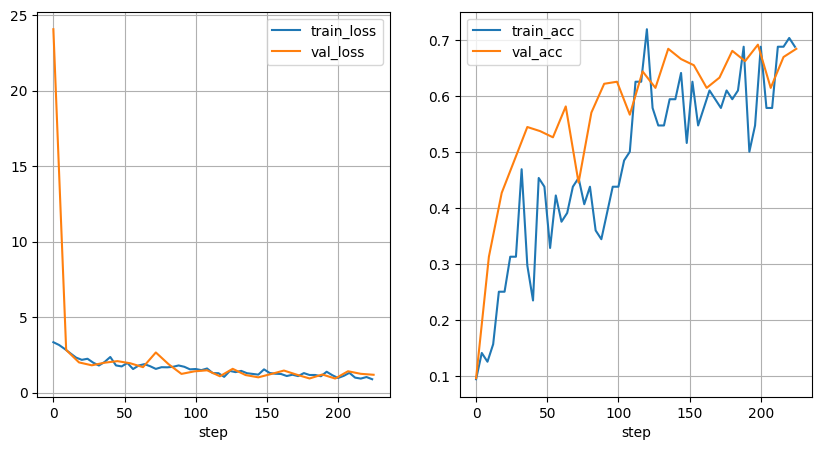

In [95]:
#画线要注意的是损失是不一定在零到1之间的
sample_step=eval_step//2
# 注意：训练损失是按采样步长展示的，不是每步都绘制，因此曲线不一定完全平滑
def plot_learning_curves(record_dict, sample_step=500):
    # 将训练记录列表转为 DataFrame，设 step 为索引
    # iloc[::sample_step] 按 sample_step 间隔采样，降低绘图密度
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    # 将验证记录列表转为 DataFrame，设 step 为索引（验证集评估频率较低，无需再采样）
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")

    # 获取需要绘制的指标数量（train_df 的列数，如 loss、acc 各一列）
    fig_num = len(train_df.columns)
    # 创建包含 fig_num 个子图的画布，每个子图宽 5 英寸、高 5 英寸
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))
    for idx, item in enumerate(train_df.columns):    
        # 绘制训练集指标曲线（横轴为全局步数 step）
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")
        # 绘制验证集指标曲线（横轴同为全局步数 step，便于对比）
        axs[idx].plot(val_df.index, val_df[item], label=f"val_{item}")
        # 显示网格线，便于读值
        axs[idx].grid()
        # 显示图例
        axs[idx].legend()
        # axs[idx].set_xticks(range(0, train_df.index[-1], 5000))
        # axs[idx].set_xticklabels(map(lambda x: f"{int(x/1000)}k", range(0, train_df.index[-1], 5000)))
        # 设置横轴标签为 "step"（全局训练步数）
        axs[idx].set_xlabel("step")
    
    # 渲染并显示图像
    plt.show()

# 传入训练记录字典，每隔 10 个训练步采样一次进行绘图（横坐标是 steps）
plot_learning_curves(record, sample_step)

## 五、模型评估

In [96]:
# 加载最优模型权重进行最终评估

# 从检查点文件中加载最优模型权重
# torch.load(): 从文件反序列化张量，参数 map_location="cpu" 表示将权重映射到 CPU（无 GPU 时也能正常运行）
# model.load_state_dict(): 将加载的参数字典填充到模型中
model.load_state_dict(torch.load(f"model_checkpoints/3_model/3_model_best.ckpt", map_location="cpu"))

# 调用 evaluating 函数在验证集上计算损失和准确率
# 返回值: loss (float) - 平均损失值; acc (float) - 准确率 (0~1)
loss, acc = evaluating(model, val_loader, loss_fct)
# 格式化打印结果，保留 4 位小数，便于对比不同模型性能
print(f"loss:     {loss:.4f}\naccuracy: {acc:.4f}")

loss:     0.9313
accuracy: 0.6912
